In [2]:
import sympy
from sympy import symbols, diff
from sympy.matrices import Matrix
from IPython.display import display, Math
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from sympy.utilities.autowrap import ufuncify

In [3]:
# The coordinates of space-time
coords = [symbols("t"), symbols("r"), symbols("theta"), symbols("phi")]

In [326]:
# Defining important constants and expressions
G, M, J, c = 1, 0.5, 0.2, 1
a = J/(M*c)
rs = 2*G*M/(c**2)
delta = (coords[1]**2)-rs*coords[1]+(a**2)
sigma = (coords[1]**2) + (a**2)*(sympy.cos(coords[2])**2)

# Coordinates
theta0 = np.pi/2
phi0 = 0
t0 = 0
r0 = 10
eps = 0

# Parameters
L = 2.5
E = 0.97
delta0 = (r0**2)-(r0*rs)+(a**2)
sigma0 = (r0**2) + (a**2)*(np.cos(theta0)**2)

In [327]:
# Calculation of Initial Velocities
v_t0 = 1/delta0 * (((r0**2)+(a**2) + 2*M*(a**2)*r0 * (np.sin(theta0)**2)/sigma0)*E - 2*M*a*r0/sigma0 * L)
v_p0 = 1/delta0 * (2 * M * a * r0/sigma0 * E + (1 - 2 * M * r0/sigma0)*L/(np.sin(theta0)**2))
v_th0 = 0
v_r0 = -1*np.sqrt((eps - (-(1 - rs * r0/sigma0) * (c**2) * v_t0**2 - 2*rs * r0 * a * (np.sin(theta0)**2)/sigma0 * c * v_t0 * v_p0
                          + sigma0 * v_th0**2 + ((r0**2) + (a**2) + rs * r0 * (a**2)/sigma0 * (np.sin(theta0)**2)) * (np.sin(theta0)**2) * v_p0 **2))*delta0/sigma0)

print(v_r0, v_t0, v_p0, v_th0)

-0.9404073500350792 1.0766495119787045 0.025385980479148182 0


In [311]:
# Defining the Metric
kerr = Matrix(4, 4, [-(1 - rs * coords[1]/sigma) * (c**2), 0, 0, -rs * coords[1] * a * (sympy.sin(coords[2])**2)/sigma * c,
				0, sigma/delta, 0, 0,
				0, 0, sigma, 0,
				-rs * coords[1] * a * (sympy.sin(coords[2])**2)/sigma * c, 0, 0,
				((coords[1]**2) + (a**2) + rs * coords[1] * (a**2)/sigma * (sympy.sin(coords[2])**2)) * (sympy.sin(coords[2])**2)])
kerr_inv = kerr.inv()

In [312]:
# Calculating the Christoffel Symbols
k_christoffel = []
for i in range(4):
	list1 = []
	for j in range(4):
		list2 = []
		for k in range(4):
			christoffel = 0
			for alpha in range(4):
				christoffel += 1/2 * kerr_inv[i, alpha] * (diff(kerr[alpha, k], coords[j]) + diff(kerr[alpha, j], coords[k]) - diff(kerr[j, k], coords[alpha]))
			list2.append(christoffel)
		list1.append(list2)
	k_christoffel.append(list1)

In [313]:
# Evaluating the four DEs
velocities = [symbols("v_t"), symbols("v_r"), symbols("v_th"), symbols("v_p")]

de0 = 0
for alpha in range(4):
    for beta in range(4):
        de0 -= k_christoffel[0][alpha][beta] * velocities[alpha] * velocities[beta]

de1 = 0
for alpha in range(4):
    for beta in range(4):
        de1 -= k_christoffel[1][alpha][beta] * velocities[alpha] * velocities[beta]

de2 = 0
for alpha in range(4):
    for beta in range(4):
        de2 -= k_christoffel[2][alpha][beta] * velocities[alpha] * velocities[beta]

de3 = 0
for alpha in range(4):
    for beta in range(4):
        de3 -= k_christoffel[3][alpha][beta] * velocities[alpha] * velocities[beta]

display(Math(sympy.latex(de0)))
display(Math(sympy.latex(de1)))
display(Math(sympy.latex(de2)))
display(Math(sympy.latex(de3)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [314]:
# Solver function
f_de0 = ufuncify([coords[1], coords[2], velocities[0],
                            velocities[1], velocities[2], velocities[3]], de0)
f_de1 = ufuncify([coords[1], coords[2], velocities[0],
                            velocities[1], velocities[2], velocities[3]], de1)
f_de2 = ufuncify([coords[1], coords[2], velocities[0],
                            velocities[1], velocities[2], velocities[3]], de2)
f_de3 = ufuncify([coords[1], coords[2], velocities[0],
                            velocities[1], velocities[2], velocities[3]], de3)
def solve(l, r):
    t, r, theta, phi, v_t, v_r, v_th, v_p = r

    # DEs for positional coordinates
    f_t = v_t
    f_r = v_r
    f_th = v_th
    f_p = v_p

    # DEs for velocities

    f_v_t = f_de0(r, theta, v_t, v_r, v_th, v_p)
    f_v_r = f_de1(r, theta, v_t, v_r, v_th, v_p)
    f_v_th = f_de2(r, theta, v_t, v_r, v_th, v_p)
    f_v_p = f_de3(r, theta, v_t, v_r, v_th, v_p)

    # REMEMBER! Christoffel Symbols are symmetric and both their symmetric terms have to be added.

    return f_t, f_r, f_th, f_p, f_v_t, f_v_r, f_v_th, f_v_p

In [315]:
sol = solve_ivp(solve, (0,2000), (t0, r0, theta0, phi0, v_t0, v_r0, v_th0, v_p0),
                t_eval=np.linspace(0,2000,10000000), rtol=1e-8, atol=1e-10, method='DOP853')

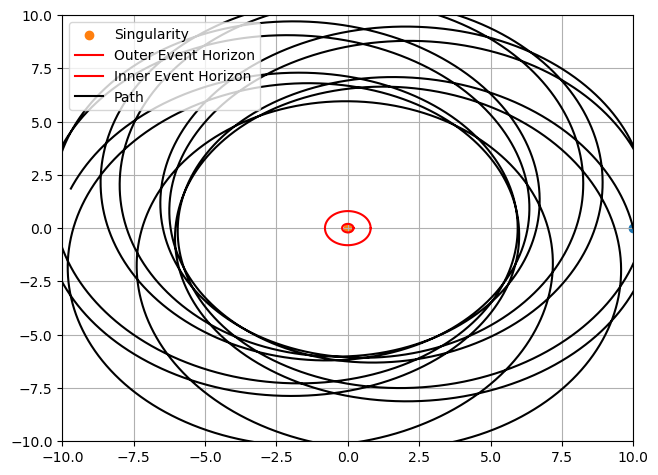

In [316]:
x = sol.y[1]*np.cos(sol.y[3])
y = sol.y[1]*np.sin(sol.y[3])

plt.scatter(x[0],y[0])
plt.scatter(0,0, label = "Singularity")
theta_c = np.linspace(0, 2*np.pi, 100)
x_c1 = (rs + np.sqrt(rs**2-4*a**2))/2 * np.cos(theta_c)
y_c1 = (rs + np.sqrt(rs**2-4*a**2))/2 * np.sin(theta_c)
plt.plot(x_c1, y_c1, color="red", label ="Outer Event Horizon")

x_c2 = (rs - np.sqrt(rs**2-4*a**2))/2 * np.cos(theta_c)
y_c2 = (rs - np.sqrt(rs**2-4*a**2))/2 * np.sin(theta_c)
plt.plot(x_c2, y_c2, color="red", label ="Inner Event Horizon")
plt.plot(x,y, color ="black", label = "Path")

plt.tight_layout()
plt.legend(loc="upper left")
plt.grid()
plt.xlim((-10,10))
plt.ylim((-10,10))
plt.show()

In [314]:
sol

  message: Required step size is less than spacing between numbers.
  success: False
   status: -1
        t: [ 0.000e+00  2.002e-01  4.004e-01  6.006e-01  8.008e-01]
        y: [[ 0.000e+00  6.820e-01 ...  2.435e+00  3.935e+00]
            [ 2.500e+00  2.112e+00 ...  1.355e+00  9.992e-01]
            ...
            [ 0.000e+00  7.498e-19 ...  8.560e-18  2.885e-17]
            [ 3.188e-01  4.767e-01 ...  1.546e+00  4.459e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 186845
     njev: 0
      nlu: 0